In [10]:
from erebus.individual_fit_results import IndividualFitResults
from erebus.wrapped_fits import WrappedFits
import numpy as np
import matplotlib.pyplot as plt
from erebus.utility.utils import bin_data, get_eclipse_duration
from scipy.optimize import curve_fit
from uncertainties import ufloat
from erebus.photometry_data import PhotometryData
from erebus.wrapped_fits import WrappedFits
import glob
from photutils.aperture import CircularAperture, CircularAnnulus, aperture_photometry
import numpy as np
from uncertainties import ufloat
from astropy import units as units
from astropy import constants as const

photo1 = PhotometryData.load("./Individual fit with fixed tsec prior/GJ3929b_photometry_0.h5")
photo2 = PhotometryData.load("./Individual fit with fixed tsec prior/GJ3929b_photometry_1.h5")
photo3 = PhotometryData.load("./Individual fit with fixed tsec prior/GJ3929b_photometry_2.h5")
photo4 = PhotometryData.load("./Individual fit with fixed tsec prior/GJ3929b_photometry_3.h5")

fits1 = WrappedFits.load(glob.glob("./wrapped fits/*00100*.h5")[0])
fits2 = WrappedFits.load(glob.glob("./wrapped fits/*00200*.h5")[0])
fits3 = WrappedFits.load(glob.glob("./wrapped fits/*00300*.h5")[0])
fits4 = WrappedFits.load(glob.glob("./wrapped fits/*00400*.h5")[0])

visit1 = IndividualFitResults.load("./Individual fit with fixed tsec prior/GJ3929b_visit_1_jw09235001001.h5")
visit2 = IndividualFitResults.load("./Individual fit with fixed tsec prior/GJ3929b_visit_2_jw09235002001.h5")
visit3 = IndividualFitResults.load("./Individual fit with fixed tsec prior/GJ3929b_visit_3_jw09235003001.h5")
visit4 = IndividualFitResults.load("./Individual fit with fixed tsec prior/GJ3929b_visit_4_jw09235004001.h5")

joint_fit = IndividualFitResults.load(glob.glob("./Aperture*/*5_fnpca*/*joint*.h5")[0])

In [11]:
# From Chris

def loadFilterTranmission(filter):
	'''
	returns filter transmission as a function of wavelength.
	'''

	#Files exist either as a .dat or a .csv. Search for both :)

	try:
		filter_wave, filter_transmission = np.loadtxt('./instruments/'+filter+'.dat', unpack=True)
	except:
		filter_wave, filter_transmission = np.loadtxt('./instruments/'+filter+'_throughput.csv', unpack=True, delimiter=',')

	return filter_wave, filter_transmission


def calcStellarFlux_mjy(filter, wave_um, Fstar_lambda, Rstar, dist, lambda_c = 15):
	'''

	Parameters
	----------
	filter - Exact filter name saved in the filter directory
	wave_um - wavelength array [um]
	Fstar_lambda - array for the stellar flux density as a function of wavelength  [W/m2 um]
	Rstar - Stellar radius [m]
	dist - distance to the star [m]
	lambda_c - central (or effective?) wavelength of the bandpass in microns

	Returns
	-------
	Absolute calibrated flux of the host star multiplied by the bandpass width in mJy * um
	-> MUST DIVIDE BY THE FILTER BANDPASS WIDTH!
	Example: the width of the F1500W filter is 2.92 microns. Divide the returned value by 2.92
	to calculate the absolute calibrated flux.
	'''
	filter_wave, filter_transmission = loadFilterTranmission(filter)
	filter_wave = filter_wave / 1e4  # convert from angstrom to micron

	# normalize the transmission
	filter_transmission = filter_transmission / np.max(filter_transmission)
	filter_transmission = np.interp(wave_um, filter_wave, filter_transmission)

	# bin_range specifies a specific region of the bandpass to analyze

	for i in range(len(filter_transmission)):
		if wave_um[i] < filter_wave[0] or wave_um[i] > filter_wave[-1]:
			filter_transmission[i] = 0

	st_flux = 4*np.pi*Rstar**2 * Fstar_lambda / (4 * np.pi * dist**2)
	st_flux = st_flux * lambda_c ** 2 / ( const.c.value * 10**6) * 1 / (10 ** (-29)) #now in mJy

	return np.trapz(st_flux*filter_transmission, wave_um)

def calcStellarFlux(filter, wave_um, Fstar_lambda, Rstar, dist, lambda_c = 15):
	'''

	Parameters
	----------
	filter - Exact filter name saved in the filter directory
	wave_um - wavelength array [um]
	Fstar_lambda - array for the stellar flux density as a function of wavelength  [W/m2 um]
	Rstar - Stellar radius [m]
	dist - distance to the star [m]
	lambda_c - central (or effective?) wavelength of the bandpass in microns

	Returns
	-------
	Absolute calibrated flux of the host star multiplied by the bandpass width in W/m2 um * um
	-> MUST DIVIDE BY THE FILTER BANDPASS WIDTH!
	Example: the width of the F1500W filter is 2.92 microns. Divide the returned value by 2.92
	to calculate the absolute calibrated flux.
	'''
	filter_wave, filter_transmission = loadFilterTranmission(filter)
	filter_wave = filter_wave / 1e4  # convert from angstrom to micron

	# normalize the transmission
	filter_transmission = filter_transmission / np.max(filter_transmission)
	filter_transmission = np.interp(wave_um, filter_wave, filter_transmission)

	# bin_range specifies a specific region of the bandpass to analyze

	for i in range(len(filter_transmission)):
		if wave_um[i] < filter_wave[0] or wave_um[i] > filter_wave[-1]:
			filter_transmission[i] = 0

	# Stellar flux in W / m2 um over the bandpass
	return np.trapz(Fstar_lambda * filter_transmission, wave_um)


In [12]:
wl, F = np.loadtxt("GJ3929_interpolatedsphinx.txt").T
model = calcStellarFlux_mjy("JWST_MIRI_F1500W", wl, F, (0.32 * const.R_sun).to(units.m).value, (15.8095 * units.pc).to(units.m).value, 15) / 2.92

F_measured_Xue = np.ones_like(wl) * 1241
xue = calcStellarFlux_mjy("JWST_MIRI_F1500W", wl, F_measured_Xue, (0.32 * const.R_sun).to(units.m).value, (15.8095 * units.pc).to(units.m).value, 15) / 2.92

In [13]:
print(xue / model)
print(model / xue)
print(model)

1.0305130835931937
0.9703903967072395
18.845324334198974


In [25]:
def get_stellar_flux_calibration(visit, fits):
	# Optimal values from Gordon et al for F1500W
	aperture_radius = 5.69
	annulus_inner_radius = 8.63
	annulus_outer_radius = 11.45

	inc = visit.results["inc"].nominal_value
	a = visit.results["a_rstar"].nominal_value
	rp = visit.results["rp_rstar"].nominal_value
	per = visit.results["p"].nominal_value
	duration = get_eclipse_duration(inc, a, rp, per) * 24

	# Use Photutils to calculate the flux
	def get_stellar_flux(frames, center):
		aperture = CircularAperture([center], r=aperture_radius)
		annulus = CircularAnnulus([center], r_in=annulus_inner_radius, r_out=annulus_outer_radius)
		
		results = []
		for frame in frames:
			aperture_flux = aperture_photometry(frame, aperture)['aperture_sum'][0]
			annulus_flux = aperture_photometry(frame, annulus)['aperture_sum'][0]
	
			background = annulus_flux * aperture.area / annulus.area
			
			net_flux = aperture_flux - background
			results.append(net_flux)
			
		return np.array(results)

	# Only take flux when the planet is eclipsed.
	# Duration is in hours, need it in days for this
	eclipse_start = (visit.predicted_t_sec + visit.results['t_sec_offset']).nominal_value - duration/48
	eclipse_end = (visit.predicted_t_sec + visit.results['t_sec_offset']).nominal_value + duration/48

	eclipse_start -= np.min(fits.time)
	eclipse_end -= np.min(fits.time)

	plt.plot(fits.time, get_stellar_flux(fits.frames, (63, 63)))
	plt.show()

	plt.imshow(fits.frames[0].T)
	plt.plot([63], [63], marker='x')
	plt.show()
	
	# Find proper indices that are within the eclipse
	t = np.array(fits.time - np.min(fits.time))
	inds = np.where((eclipse_start < t) & (eclipse_end > t))
	print(inds)
	f = get_stellar_flux(fits.frames[inds], (63, 63))

	t_hours = (t[inds] - np.min(t[inds])) * 24
	plt.axvline(np.min(t_hours), color='black', linestyle='--')
	plt.axvline(np.max(t_hours), color='black', linestyle='--')
	plt.plot(t_hours, f)
	plt.ylabel("Flux within aperture (DN)")
	plt.xlabel("Time since start of eclipse (hours)")
	plt.show()

	# Length of each integration (seconds)
	dt = duration * 3600 / len(fits.time[inds])
	# Aperture area in pixels
	aperture_area = np.pi * aperture_radius**2
	print("Eclipse duration: ", duration, "hours")
	print("Aperture area: ", aperture_area, "square pixels")
	print("Length of integrations: ", dt, "seconds")
	
	# Aperture correction factor from Gordon et al
	A_corr = ufloat(1.497, 0.019)
	
	# Inidivudal pixel sizes from MIRI docs
	pixel_solid_angle = (((0.11 * units.arcsec).to(units.rad))**2).value
	
	# Calibration factor depends on time, using coefficients for MIRI F1500W and SUB128 array
	def calibration_factor(t):
		A = 0.3703
		B = -0.0107  
		tau = 200    #Days
		t0 = 59720   #In MJD
		D_sa = 1     #SUB128

		# Units of (MJy/sr) / (DN/s*pixel)
		return (A + B * np.exp(-(t - t0)/tau)) / D_sa

	# Calibration factors within the eclipse
	C = np.array([calibration_factor(t) for t in fits.time[inds]]) 
	# DN / s * pixel within the eclipse
	# f is in DN / s pixel
	N_ap = f 
	
	print("A_corr: " , A_corr)
	print("Omega_pix: ", pixel_solid_angle, "sr")
	print("Aperture area: ", aperture_area, "pixels")
	
	print("Average calibration factor: ", np.mean(C), "(MJy/sr) / (DN/s/pixel)")
	print("Average DN/s/pixel: ", np.mean(N_ap))
	
	calibrated_fluxes = np.array([(N_ap_i * A_corr * pixel_solid_angle * Ci) for N_ap_i, Ci in zip(N_ap, C)])

	# Converted from MJy to mJy
	calibrated_flux = np.mean(calibrated_fluxes) * 1e9
	
	print("Calibrated flux: ", calibrated_flux, "mJy")
	
	return calibrated_flux

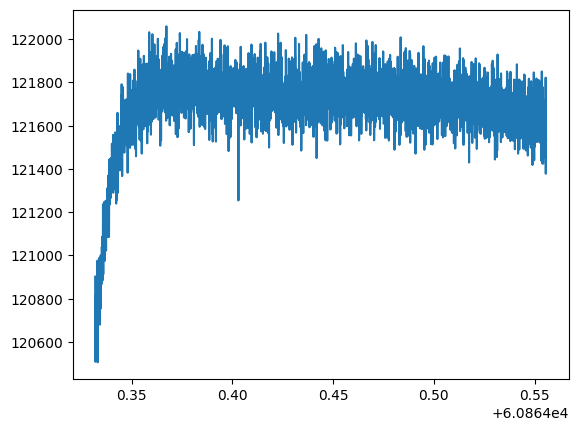

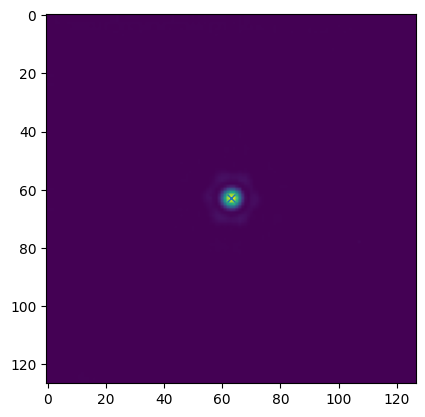

(array([1050, 1051, 1052, 1053, 1054, 1055, 1056, 1057, 1058, 1059, 1060,
       1061, 1062, 1063, 1064, 1065, 1066, 1067, 1068, 1069, 1070, 1071,
       1072, 1073, 1074, 1075, 1076, 1077, 1078, 1079, 1080, 1081, 1082,
       1083, 1084, 1085, 1086, 1087, 1088, 1089, 1090, 1091, 1092, 1093,
       1094, 1095, 1096, 1097, 1098, 1099, 1100, 1101, 1102, 1103, 1104,
       1105, 1106, 1107, 1108, 1109, 1110, 1111, 1112, 1113, 1114, 1115,
       1116, 1117, 1118, 1119, 1120, 1121, 1122, 1123, 1124, 1125, 1126,
       1127, 1128, 1129, 1130, 1131, 1132, 1133, 1134, 1135, 1136, 1137,
       1138, 1139, 1140, 1141, 1142, 1143, 1144, 1145, 1146, 1147, 1148,
       1149, 1150, 1151, 1152, 1153, 1154, 1155, 1156, 1157, 1158, 1159,
       1160, 1161, 1162, 1163, 1164, 1165, 1166, 1167, 1168, 1169, 1170,
       1171, 1172, 1173, 1174, 1175, 1176, 1177, 1178, 1179, 1180, 1181,
       1182, 1183, 1184, 1185, 1186, 1187, 1188, 1189, 1190, 1191, 1192,
       1193, 1194, 1195, 1196, 1197, 1198, 1199, 1

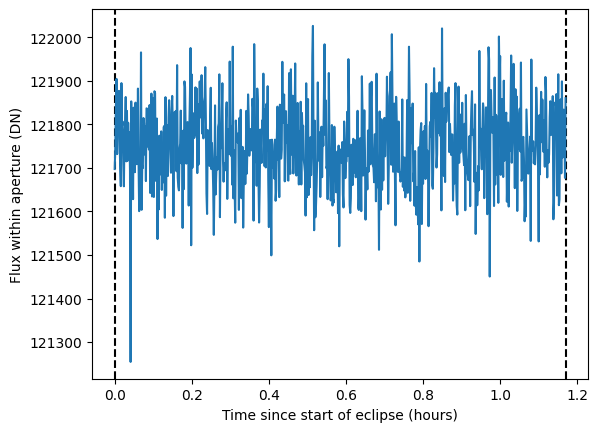

Eclipse duration:  1.1714848209895314 hours
Aperture area:  101.7125179118885 square pixels
Length of integrations:  5.714560102387957 seconds
A_corr:  1.497+/-0.019
Omega_pix:  2.8440360952308436e-13 sr
Aperture area:  101.7125179118885 pixels
Average calibration factor:  0.37026498169407196 (MJy/sr) / (DN/s/pixel)
Average DN/s/pixel:  121751.84846177087
Calibrated flux:  19.19+/-0.24 mJy


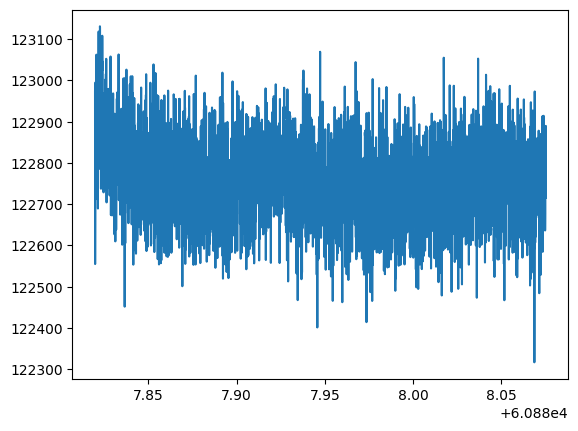

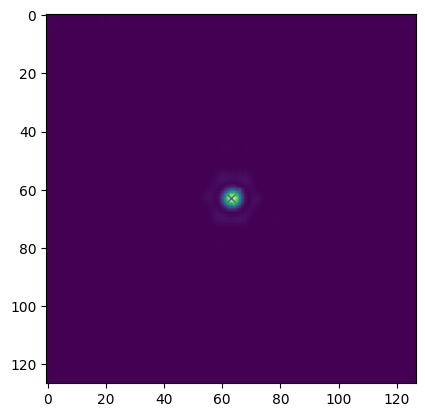

(array([1865, 1866, 1867, 1868, 1869, 1870, 1871, 1872, 1873, 1874, 1875,
       1876, 1877, 1878, 1879, 1880, 1881, 1882, 1883, 1884, 1885, 1886,
       1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897,
       1898, 1899, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908,
       1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919,
       1920, 1921, 1922, 1923, 1924, 1925, 1926, 1927, 1928, 1929, 1930,
       1931, 1932, 1933, 1934, 1935, 1936, 1937, 1938, 1939, 1940, 1941,
       1942, 1943, 1944, 1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952,
       1953, 1954, 1955, 1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963,
       1964, 1965, 1966, 1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974,
       1975, 1976, 1977, 1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985,
       1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996,
       1997, 1998, 1999, 2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007,
       2008, 2009, 2010, 2011, 2012, 2013, 2014, 2

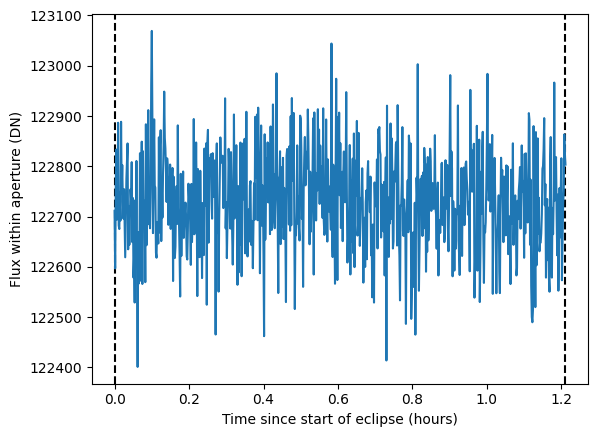

Eclipse duration:  1.2123269367384975 hours
Aperture area:  101.7125179118885 square pixels
Length of integrations:  5.712535304003391 seconds
A_corr:  1.497+/-0.019
Omega_pix:  2.8440360952308436e-13 sr
Aperture area:  101.7125179118885 pixels
Average calibration factor:  0.3702688704561916 (MJy/sr) / (DN/s/pixel)
Average DN/s/pixel:  122730.15569853284
Calibrated flux:  19.35+/-0.25 mJy


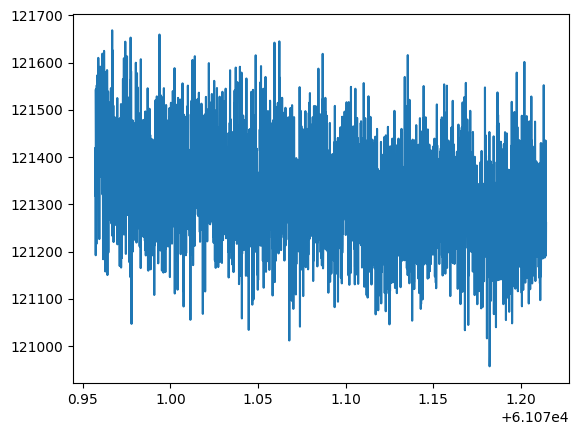

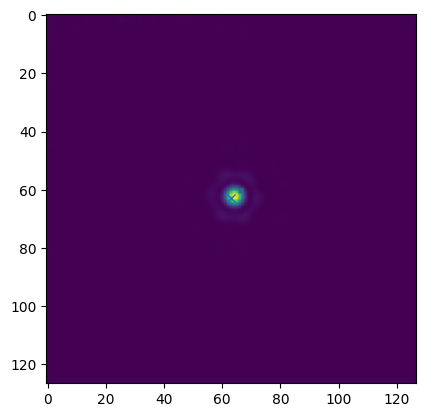

(array([1945, 1946, 1947, 1948, 1949, 1950, 1951, 1952, 1953, 1954, 1955,
       1956, 1957, 1958, 1959, 1960, 1961, 1962, 1963, 1964, 1965, 1966,
       1967, 1968, 1969, 1970, 1971, 1972, 1973, 1974, 1975, 1976, 1977,
       1978, 1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988,
       1989, 1990, 1991, 1992, 1993, 1994, 1995, 1996, 1997, 1998, 1999,
       2000, 2001, 2002, 2003, 2004, 2005, 2006, 2007, 2008, 2009, 2010,
       2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021,
       2022, 2023, 2024, 2025, 2026, 2027, 2028, 2029, 2030, 2031, 2032,
       2033, 2034, 2035, 2036, 2037, 2038, 2039, 2040, 2041, 2042, 2043,
       2044, 2045, 2046, 2047, 2048, 2049, 2050, 2051, 2052, 2053, 2054,
       2055, 2056, 2057, 2058, 2059, 2060, 2061, 2062, 2063, 2064, 2065,
       2066, 2067, 2068, 2069, 2070, 2071, 2072, 2073, 2074, 2075, 2076,
       2077, 2078, 2079, 2080, 2081, 2082, 2083, 2084, 2085, 2086, 2087,
       2088, 2089, 2090, 2091, 2092, 2093, 2094, 2

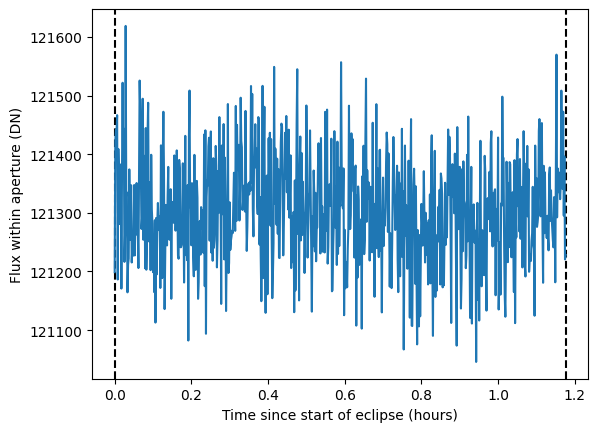

Eclipse duration:  1.177379480145037 hours
Aperture area:  101.7125179118885 square pixels
Length of integrations:  5.71235327294088 seconds
A_corr:  1.497+/-0.019
Omega_pix:  2.8440360952308436e-13 sr
Aperture area:  101.7125179118885 pixels
Average calibration factor:  0.370287540942179 (MJy/sr) / (DN/s/pixel)
Average DN/s/pixel:  121304.15147630178
Calibrated flux:  19.12+/-0.24 mJy


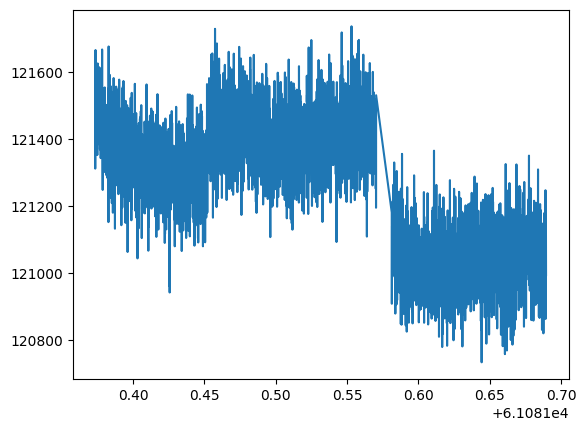

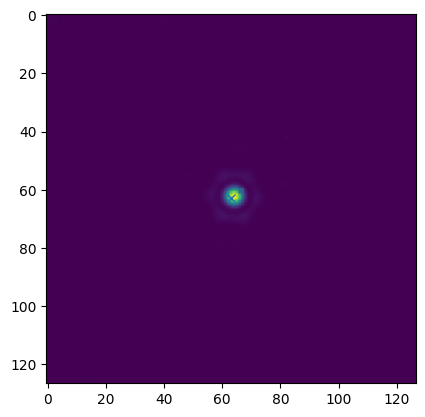

(array([2726, 2727, 2728, 2729, 2730, 2731, 2732, 2733, 2734, 2735, 2736,
       2737, 2738, 2739, 2740, 2741, 2742, 2743, 2744, 2745, 2746, 2747,
       2748, 2749, 2750, 2751, 2752, 2753, 2754, 2755, 2756, 2757, 2758,
       2759, 2760, 2761, 2762, 2763, 2764, 2765, 2766, 2767, 2768, 2769,
       2770, 2771, 2772, 2773, 2774, 2775, 2776, 2777, 2778, 2779, 2780,
       2781, 2782, 2783, 2784, 2785, 2786, 2787, 2788, 2789, 2790, 2791,
       2792, 2793, 2794, 2795, 2796, 2797, 2798, 2799, 2800, 2801, 2802,
       2803, 2804, 2805, 2806, 2807, 2808, 2809, 2810, 2811, 2812, 2813,
       2814, 2815, 2816, 2817, 2818, 2819, 2820, 2821, 2822, 2823, 2824,
       2825, 2826, 2827, 2828, 2829, 2830, 2831, 2832, 2833, 2834, 2835,
       2836, 2837, 2838, 2839, 2840, 2841, 2842, 2843, 2844, 2845, 2846,
       2847, 2848, 2849, 2850, 2851, 2852, 2853, 2854, 2855, 2856, 2857,
       2858, 2859, 2860, 2861, 2862, 2863, 2864, 2865, 2866, 2867, 2868,
       2869, 2870, 2871, 2872, 2873, 2874, 2875, 2

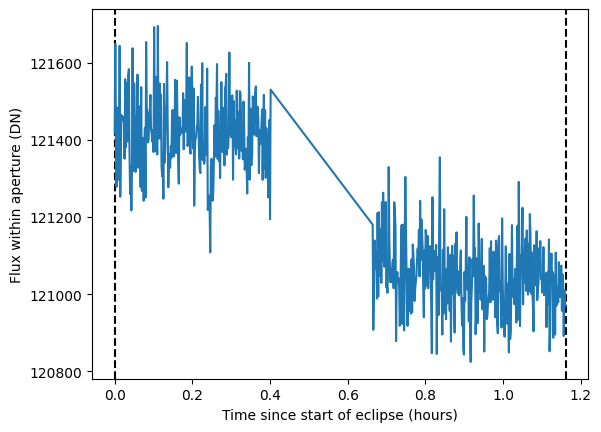

Eclipse duration:  1.1633838424881362 hours
Aperture area:  101.7125179118885 square pixels
Length of integrations:  7.373559565065652 seconds
A_corr:  1.497+/-0.019
Omega_pix:  2.8440360952308436e-13 sr
Aperture area:  101.7125179118885 pixels
Average calibration factor:  0.3702881762903158 (MJy/sr) / (DN/s/pixel)
Average DN/s/pixel:  121213.48076573233
Calibrated flux:  19.11+/-0.24 mJy
Measured:  19.19+/-0.12
Model:  18.845324334198974
Measured / model:  1.018+/-0.006


In [26]:
visit1_flux = get_stellar_flux_calibration(visit1, fits1)
visit2_flux = get_stellar_flux_calibration(visit2, fits2)
visit3_flux = get_stellar_flux_calibration(visit3, fits3)
visit4_flux = get_stellar_flux_calibration(visit4, fits4)

flux = np.mean([visit1_flux, visit2_flux, visit3_flux, visit4_flux])

print("Measured: ", flux)
print("Model: ", model)
print("Measured / model: ", flux / model)